Original Dataset:

   Income Credit Employment     Loan
0    High   Good        Yes  Approve
1    High   Good        Yes  Approve
2    High    Bad        Yes  Approve
3  Medium   Good        Yes  Approve
4  Medium    Bad         No   Reject
5     Low   Good         No   Reject
6     Low    Bad         No   Reject
7     Low    Bad        Yes   Reject

Encoded Dataset:

   Income  Credit  Employment  Loan
0       0       1           1     0
1       0       1           1     0
2       0       0           1     0
3       2       1           1     0
4       2       0           0     1
5       1       1           0     1
6       1       0           0     1
7       1       0           1     1

Decision Tree Model Trained Successfully!

Prediction for New Applicant:
Loan = REJECT


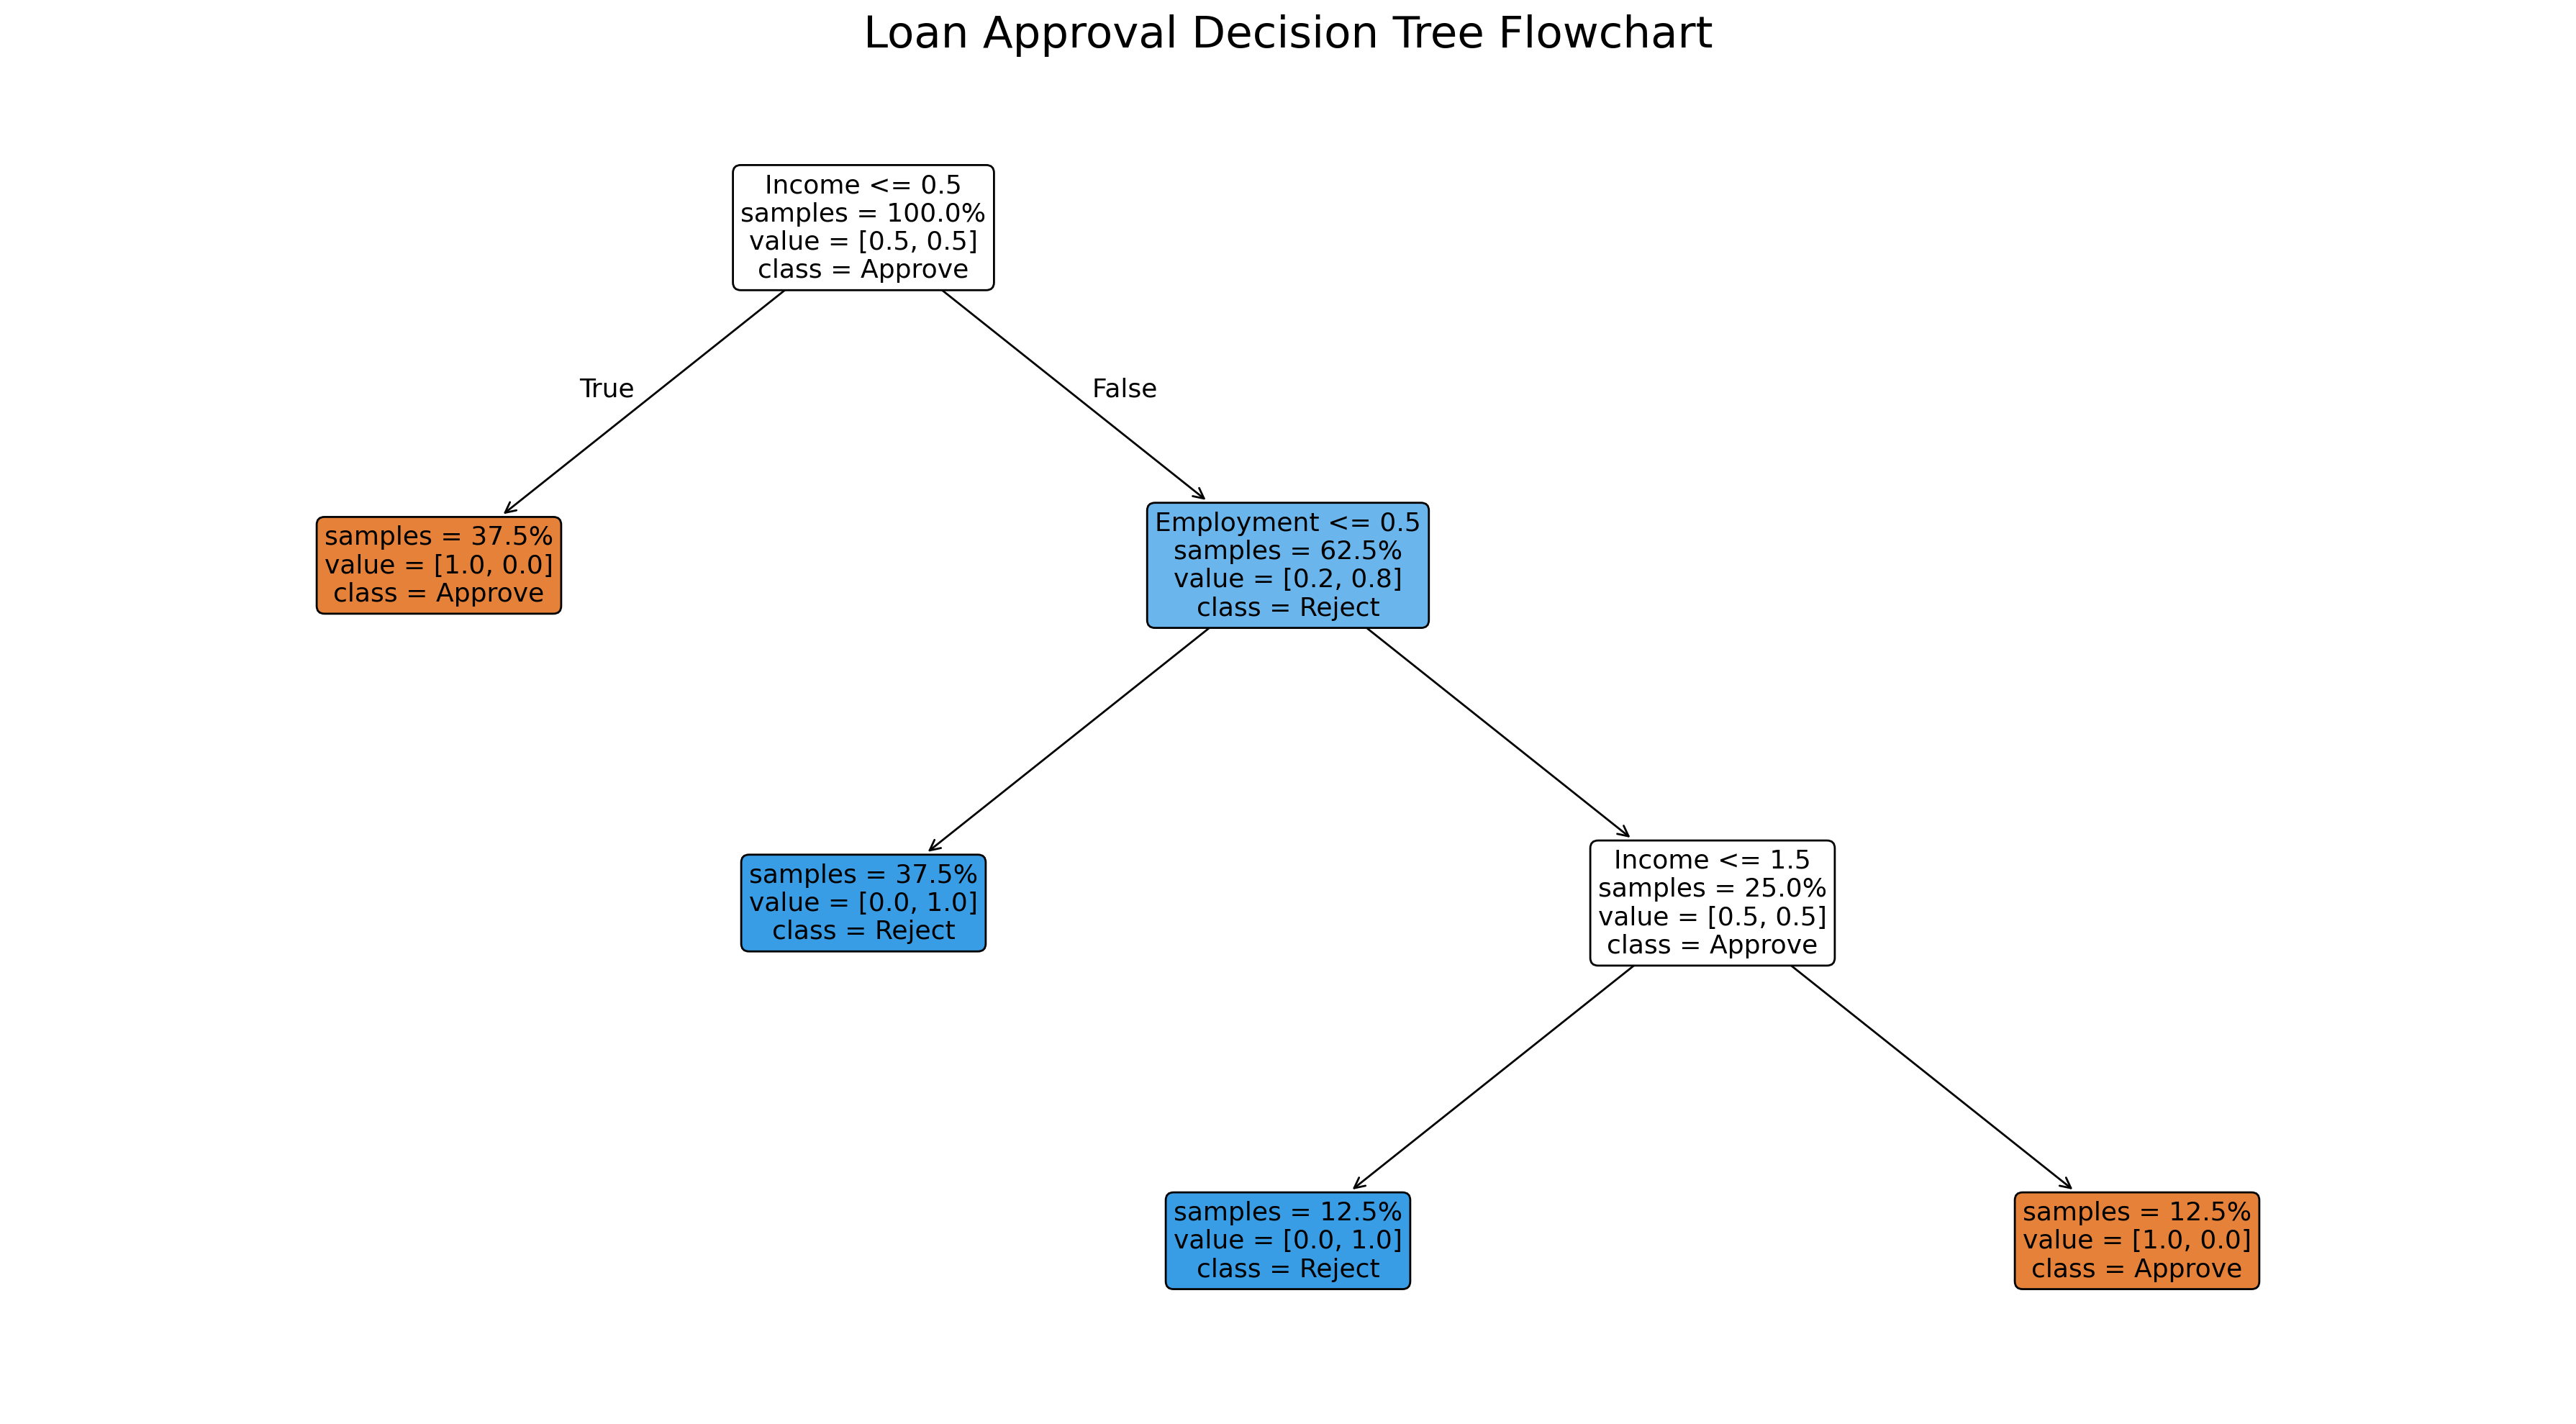

In [18]:
# Decision Tree for Loan Approval Dataset

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

# --------------------------------------------------
# Step 1: Create Dataset
# --------------------------------------------------

data = {
    'Income':     ['High','High','High','Medium','Medium','Low','Low','Low'],
    'Credit':     ['Good','Good','Bad','Good','Bad','Good','Bad','Bad'],
    'Employment': ['Yes','Yes','Yes','Yes','No','No','No','Yes'],
    'Loan':       ['Approve','Approve','Approve','Approve','Reject','Reject','Reject','Reject']
}

df = pd.DataFrame(data)

print("Original Dataset:\n")
print(df)


# --------------------------------------------------
# Step 2: Label Encoding (text → numbers)
# --------------------------------------------------

le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

print("\nEncoded Dataset:\n")
print(df)


# --------------------------------------------------
# Step 3: Split Features and Target
# --------------------------------------------------

X = df[['Income', 'Credit', 'Employment']]
y = df['Loan']


# --------------------------------------------------
# Step 4: Train Decision Tree (Entropy)
# --------------------------------------------------

model = DecisionTreeClassifier(
    criterion='entropy',   # using entropy + information gain
    max_depth=3,
    random_state=0
)

model.fit(X, y)

print("\nDecision Tree Model Trained Successfully!")


# --------------------------------------------------
# Step 5: Predict New Sample
# Example: Medium income, Good credit, No employment
# --------------------------------------------------

new_sample = pd.DataFrame({
    'Income':[2],      # Medium
    'Credit':[1],      # Good
    'Employment':[0]   # No
})

prediction = model.predict(new_sample)

print("\nPrediction for New Applicant:")
print("Loan =", "APPROVE" if prediction[0]==0 else "REJECT")


# --------------------------------------------------
# Step 6: Plot Decision Tree
# --------------------------------------------------
# --------------------------------------------------
# Step 6: Plot Decision Tree (CLEAN FLOWCHART STYLE)
# --------------------------------------------------

plt.figure(figsize=(18,10), dpi=200)   # bigger + sharp image

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Approve','Reject'],
    filled=True,
    rounded=True,
    fontsize=13,        # bigger text
    proportion=True,    # better spacing between nodes
    impurity=False,     # remove entropy text (clean look)
    precision=1
)

plt.title("Loan Approval Decision Tree Flowchart", fontsize=22)
plt.tight_layout()

# save high-quality image
plt.savefig("Loan_Approval_Tree.png", bbox_inches='tight')

plt.show()
